# **Getting Requirements**

This uses Python 3.10.x 

In [1]:
! pip install matplotlib pandas mplfinance marketprofile plotly yfinance-cache
! pip install yfinance --upgrade --no-cache-dir
! pip install --upgrade nbformat
! pip install IPython IPython notebook tabulate textblob Newspaper3k


In [2]:
# Standard library imports
from datetime import datetime, timedelta
import json
import logging
import time
import concurrent.futures

# Third-party imports
import matplotlib.pyplot as plt
import mplfinance as mpf
import numpy as np
from newspaper import Article
import pandas as pd
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from IPython.display import display, Markdown
from tabulate import tabulate
from textblob import TextBlob
from tqdm import tqdm
import yfinance as yf

# Local application/library specific imports
from market_profile import MarketProfile

# Configure logging
logging.basicConfig(level=40)  # INFO level logging

In [3]:
file_path = './tickers.csv'  # Updated to a relative path for broader applicability

try:
    # Try loading the file. Adjust encoding if needed.
    data = pd.read_csv(file_path, encoding='ISO-8859-1')

    # Define the set of expected columns for validation.
    expected_columns = {'ticker'}

    # Check if the expected columns are present in the loaded data.
    if set(data.columns) & expected_columns == expected_columns:
        print('CSV file loaded successfully with the expected headers.')
        companies = data['ticker'].tolist()
    else:
        missing_columns = expected_columns - set(data.columns)
        print(f'CSV file is missing the following required columns: {missing_columns}')
        companies = []
except Exception as e:
    print(f'An error occurred while loading the CSV file: {e}')
    companies = []

# print("Total number of initial companies is: " + len(companies))

# Adjust or confirm the cache folder path as per your environment.
cache_folder = './colab_cache/'  # Adjusted to a more generic path unless you are specifically working within Google Colab.

def populate_metrics(ticker, metrics):
    if ticker and hasattr(ticker, 'info'):
        stock_info = ticker.info
        metrics['eps_values'].append(stock_info.get('trailingEps', 0))
        metrics['pe_values'].append(stock_info.get('trailingPE', 0))
        metrics['peg_values'].append(stock_info.get('pegRatio', 0))
        metrics['gross_margins'].append(stock_info.get('grossMargins', 0))
        metrics['company_labels'].append(ticker.ticker)
    else:
        print(f"Skipped a company ticker due to missing info or an invalid object.")

def worker(company, metrics):
    try:
        ticker = yf.Ticker(company)
        populate_metrics(ticker, metrics)
    except Exception as e:
        print(f"Failed to fetch data for {company}. Error: {e}")

def fetch_metrics_data(companies):
    metrics = {metric: [] for metric in ['eps_values', 'pe_values', 'peg_values', 'gross_margins', 'company_labels']}

    with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
        futures = [executor.submit(worker, company, metrics) for company in companies]

        for i, future in enumerate(tqdm(concurrent.futures.as_completed(futures), total=len(companies), desc="Fetching metrics")):
            # This loop is primarily to keep tqdm updated, handling of results (if any) would go here

            # Pause for 2 seconds after every 500 requests
            if i != 0 and i % 1000 == 0:
                time.sleep(30)

    return metrics

# Example of usage
metrics = fetch_metrics_data(companies)

CSV file loaded successfully with the expected headers.


Fetching metrics: 100%|██████████| 3350/3350 [01:56<00:00, 28.82it/s]  


# **Parametters**

Here fix parameters for the initial screener. Would rather keep it bit open at this stage and not be very restrictive. 
Using 3 metrics: EPS, GM, and PEG.

In [16]:
days_history = 365 * 10  
interval_dates = '3mo'

eps_threshold = 1
gross_margin_threshold = 0.8 # 0.5 means 50%

peg_threshold_low = 0
peg_threshold_high = 1.5

In [5]:
def get_date_range(days_back):
    """Helper function to compute start and end date strings."""
    end_date = datetime.now()
    start_date = end_date - timedelta(days=days_back)
    return start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d')

start_date_str, end_date_str = get_date_range(days_history)

# **Filtering Methods**

In [6]:
def filter_companies(metrics, eps_threshold, peg_threshold_low, peg_threshold_high, gross_margin_threshold): 
    
    try:

        if not isinstance(metrics, dict):
            raise ValueError("metrics must be a dictionary")
        required_keys = ['company_labels', 'eps_values', 'pe_values', 'peg_values', 'gross_margins']
        for key in required_keys:
            if key not in metrics:
                raise KeyError(f"Key '{key}' not found in metrics")
            if not isinstance(metrics[key], list):
                raise TypeError(f"Value of '{key}' must be a list")
            if not metrics[key]:
                raise ValueError(f"List for '{key}' is empty")

        if not (isinstance(eps_threshold, (int, float)) and isinstance(peg_threshold_low, (int, float)) and isinstance(peg_threshold_high, (int, float)) and isinstance(gross_margin_threshold, (int, float))):
            raise TypeError("Thresholds must be numeric")

        if peg_threshold_low >= peg_threshold_high:
            raise ValueError("peg_threshold_low must be less than peg_threshold_high")

        df = pd.DataFrame({
            'company': metrics['company_labels'],
            'eps': metrics['eps_values'],
            'pe': metrics['pe_values'],
            'peg': metrics['peg_values'],
            'gross_margin': metrics['gross_margins']
        })

        if df['gross_margin'].max() <= 1:
            df['gross_margin'] *= 100

        criteria = (df['eps'] > eps_threshold) & \
                (df['gross_margin'] > gross_margin_threshold) & \
                (df['peg'] > peg_threshold_low) & (df['peg'] <= peg_threshold_high)

        filtered_df = df[criteria]

        filtered_df_sorted = filtered_df.sort_values(by='pe', ascending=True)

        print(f"Filtered down to {len(filtered_df_sorted)} companies based on criteria.")

        return filtered_df_sorted

    except Exception as e:
        print(f"An error occurred: {e}")
        return pd.DataFrame()

def classify_by_industry(tickers):
    industries = {}
    for ticker in tickers.tickers.values():
        sector = ticker.info.get('sector')
        if sector:
            industries.setdefault(sector, []).append(ticker.ticker)
    return industries

def fetch_industries(companies):
    tickers = yf.Tickers(' '.join(companies))
    industries = classify_by_industry(tickers)
    return industries

def fetch_recommendations_summary(ticker):
    try:
        rec_data = ticker.get_recommendations_summary()

        if not rec_data.empty:
            return {
                row['period']: {
                    'strongBuy': row['strongBuy'],
                    'buy': row['buy'],
                    'hold': row['hold'],
                    'sell': row['sell'],
                    'strongSell': row['strongSell']
                } for index, row in rec_data.iterrows()
            }
        else:
            return {"message": "No recommendation data available."}
    except Exception as e:
        return {"error": f"Error: {str(e)}"}

def populate_additional_metrics(ticker, metrics):
    if not hasattr(ticker, 'info') or not hasattr(ticker, 'cashflow'):
        raise AttributeError("The ticker object must have 'info' and 'cashflow' attributes")

    try:
        stock_info = ticker.info
    except Exception as e:
        print(f"Failed to fetch stock info: {e}")
        return metrics  

    try:
        recommendations_summary = fetch_recommendations_summary(ticker)
        metrics['recommendations_summary'].append(recommendations_summary)
    except Exception as e:
        print(f"Failed to fetch recommendations summary: {e}")
        metrics['recommendations_summary'].append(None)  

    metrics['ps_values'].append(stock_info.get('priceToSalesTrailing12Months', 0))
    metrics['pb_values'].append(stock_info.get('priceToBook', 0))
    metrics['market_caps'].append(stock_info.get('marketCap', 0))

    fields_to_add = {
        'forwardPE': 'forwardPE',
        'profitMargins': 'profitMargins',
        'heldPercentInsiders': 'heldPercentInsiders',
        'heldPercentInstitutions': 'heldPercentInstitutions',
        'forwardEps': 'forwardEps',
        'recommendationMean': 'recommendationMean',
        'recommendationKey': 'recommendationKey',
        'numberOfAnalystOpinions': 'numberOfAnalystOpinions',
        'totalCashPerShare': 'totalCashPerShare',
        'debtToEquity': 'debtToEquity',
        'earningsGrowth': 'earningsGrowth',
        'revenueGrowth': 'revenueGrowth',
        'freeCashflow': None,
        'opCashflow': None,
        'repurchaseCapStock': None,
    }

    try:
        df = ticker.cashflow
    except Exception as e:
        print(f"Failed to fetch cashflow data: {e}")
        df = None  

    for key, value in fields_to_add.items():
        if key not in metrics:
            metrics[key] = [] 

        if df is not None and key in ['freeCashflow', 'opCashflow', 'repurchaseCapStock']:
            try:
                if key == 'freeCashflow':
                    free_cash_flow = df.iloc[0, :].tolist()
                    metrics[key].append(free_cash_flow)
                elif key == 'opCashflow':
                    op_cash_flow = df.iloc[33, :].tolist()
                    metrics[key].append(op_cash_flow)
                elif key == 'repurchaseCapStock':
                    repurchase_capital_stock = df.iloc[1, :].tolist()
                    metrics[key].append(repurchase_capital_stock)
            except Exception as e:
                print(f"{ticker.ticker} Failed to process {key}: {e}")
                metrics[key].append(None)  
        else:
            metrics[key].append(stock_info.get(value, 0))  

    return metrics

def augment_metrics_with_live_data(companies, original_metrics):
    if not isinstance(companies, list) or not all(isinstance(item, str) for item in companies):
        raise ValueError("companies must be a list of strings")

    if not isinstance(original_metrics, dict):
        raise ValueError("original_metrics must be a dictionary")

    augmented_data = {metric: [] for metric in original_metrics}  

    augmented_data.update({  
        'recommendations_summary': [],
        'news': [],
        'ps_values': [],
        'pb_values': [],
        'market_caps': []
    })

    for company_symbol in companies:
        try:
            ticker = get_ticker_object(company_symbol)

            company_metrics = {metric: [] for metric in augmented_data}

            populate_additional_metrics(ticker, company_metrics)

            for key, values in company_metrics.items():
                if key in augmented_data:
                    augmented_data[key].extend(values if isinstance(values, list) else [values])
                else:
                    print(f"Unexpected metric {key} found in company_metrics, skipping...")
        except Exception as e:
            print(f"Error processing company {company_symbol}: {e}")

    return augmented_data

def get_ticker_object(symbol):
    if not isinstance(symbol, str):
        raise ValueError("Symbol must be a string.")

    ticker = yf.Ticker(symbol)
    return ticker

def fetch_additional_metrics_data(companies):
    """Fetches and structures various financial metrics for the given list of company tickers."""
    tickers = yf.Tickers(' '.join(companies))
    metrics = {metric: [] for metric in ['ps_values', 'pb_values',
                                     'market_caps', 'recommendations_summary']}
    metrics['price_diff'] = {}

    for company in companies:
        try:
            ticker = tickers.tickers[company]
            populate_additional_metrics(ticker, metrics)
        except KeyError:
            print(f"Warning: Ticker {company} not found. Skipping.")

    return metrics

def build_combined_metrics(filtered_company_symbols, metrics, metrics_filtered):
    if not isinstance(filtered_company_symbols, list):
        raise ValueError("filtered_company_symbols must be a list")
    if not isinstance(metrics, dict):
        raise ValueError("metrics must be a dictionary")
    if not isinstance(metrics_filtered, dict):
        raise ValueError("metrics_filtered must be a dictionary")

    metrics.pop('companies_fetched', None)
    metrics_filtered.pop('companies_fetched', None)

    combined_keys = set(metrics.keys()).union(metrics_filtered.keys()) - {'company_labels', 'companies_fetched'}
    combined_metrics = {key: [] for key in combined_keys}

    combined_metrics['company_labels'] = filtered_company_symbols

    for symbol in filtered_company_symbols:
        if 'company_labels' in metrics and not isinstance(metrics['company_labels'], list):
            raise ValueError("'company_labels' in metrics must be a list")

        metrics_index = metrics['company_labels'].index(symbol) if 'company_labels' in metrics and symbol in metrics['company_labels'] else -1

        for key in combined_metrics:
            if key == 'company_labels':
                continue

            if key in metrics and metrics_index >= 0:
                value = metrics[key][metrics_index] if isinstance(metrics[key], list) and len(metrics[key]) > metrics_index else None
                combined_metrics[key].append(value)
            elif key in metrics_filtered:
                filtered_index = filtered_company_symbols.index(symbol)
                value = metrics_filtered[key][filtered_index] if isinstance(metrics_filtered[key], list) and len(metrics_filtered[key]) > filtered_index else None
                combined_metrics[key].append(value)
            else:
                combined_metrics[key].append(None)

    expected_length = len(filtered_company_symbols)
    for key, values_list in combined_metrics.items():
        if len(values_list) != expected_length:
            raise ValueError(f"Length mismatch in combined metrics for key: {key}")

    return combined_metrics

In [17]:
filtered_companies_df = filter_companies(metrics, eps_threshold, peg_threshold_low, peg_threshold_high, gross_margin_threshold)

filtered_company_symbols = filtered_companies_df['company'].tolist()

metrics_filtered = fetch_additional_metrics_data(filtered_company_symbols)

combined_metrics = build_combined_metrics(filtered_company_symbols, metrics, metrics_filtered)

filtered_industries = fetch_industries(filtered_company_symbols)

Filtered down to 44 companies based on criteria.
MFIC Failed to process opCashflow: single positional indexer is out-of-bounds
BCSF Failed to process opCashflow: single positional indexer is out-of-bounds
MAIN Failed to process opCashflow: single positional indexer is out-of-bounds
GBDC Failed to process opCashflow: single positional indexer is out-of-bounds
OCSL Failed to process opCashflow: single positional indexer is out-of-bounds
HASI Failed to process opCashflow: single positional indexer is out-of-bounds


In [18]:
def fetch_historical_data(ticker, start_date, end_date, period=None, interval='3mo'):
    try:
        if period:
            data = ticker.history(period=period, interval=interval)
        else:
            data = ticker.history(start=start_date, end=end_date, interval=interval)
        return data
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")
        return pd.DataFrame()  # Return an empty DataFrame

def calculate_price_diff(companies):
    tickers = yf.Tickers(' '.join(companies))
    price_diff = {}  # Store price difference info here

    for company in companies:
        ticker = tickers.tickers[company]
        try:
            hist = fetch_historical_data(ticker, None, None, period="1y")
            if not hist.empty:
                today_price = hist['Close'].iloc[-1]
                high_52week = max(hist['High'])
                low_52week = min(hist['Low'])
                high_percent_diff = ((today_price - high_52week) / high_52week) * 100
                low_percent_diff = ((today_price - low_52week) / low_52week) * 100
                price_diff[company] = {'high_diff': -1 * high_percent_diff, 'low_diff': low_percent_diff}
        except Exception as e:
            print(f"Error processing data for {company}: {e}")

    return price_diff

def fetch_price_diff(companies, combined_metrics):
    try:
        price_diff = calculate_price_diff(companies)

        if price_diff is not None and not price_diff: 
            print("No price difference data was found for the provided companies.")
        else:
            combined_metrics['price_diff'] = price_diff
    except Exception as e:
        print(f"An error occurred while fetching price differences: {e}")
    finally:
        return combined_metrics

def plot_sector_distribution_interactive(industries, title):
    sector_counts = {sector: len(tickers) for sector, tickers in industries.items()}

    labels = list(sector_counts.keys())
    sizes = list(sector_counts.values())

    fig = go.Figure(data=[go.Pie(labels=labels, values=sizes, hole=.3)])

    fig.update_layout(
        title_text=title,
        annotations=[dict(text='Sectors', x=0.50, y=0.5, font_size=20, showarrow=False)]
    )

    fig.show()

def plot_combined_interactive(combined_metrics):
    if not combined_metrics or not isinstance(combined_metrics, dict):
        raise ValueError("combined_metrics must be a non-empty dictionary.")

    company_labels = combined_metrics.get('company_labels', [])
    eps_values = combined_metrics.get('eps_values', [])

    if not all(len(lst) == len(company_labels) for lst in [eps_values]):
        raise ValueError("Inconsistent data lengths found in combined_metrics.")

    high_diffs = [combined_metrics['price_diff'].get(company, {}).get('high_diff', 0) for company in company_labels]
    low_diffs = [combined_metrics['price_diff'].get(company, {}).get('low_diff', 0) for company in company_labels]
    market_caps = combined_metrics.get('market_caps', [])
    pb_values = combined_metrics.get('pb_values', [])
    pe_values = combined_metrics.get('pe_values', [])
    peg_values = combined_metrics.get('peg_values', [])
    ps_values = combined_metrics.get('ps_values', [])
    gross_margins = combined_metrics.get('gross_margins', [])
    recommendations_summary = combined_metrics.get('recommendations_summary', [])
    earningsGrowth = combined_metrics.get('earningsGrowth', [])
    revenueGrowth = combined_metrics.get('revenueGrowth', [])
    freeCashflow = combined_metrics.get('freeCashflow', [])
    opCashflow = combined_metrics.get('opCashflow', [])
    repurchaseCapStock = combined_metrics.get('repurchaseCapStock', [])

    peg_min, peg_max = min(peg_values, default=0), max(peg_values, default=1)

    fig = make_subplots(rows=4, cols=3, subplot_titles=("Price Difference % Over the Last Year", "EPS vs P/E Ratio", "Gross Margin (%)", "EPS vs P/B Ratio", "EPS vs PEG Ratio", "EPS vs P/S Ratio", "Upgrades & Downgrades Timeline", "Earnings Growth vs Revenue Growth", "Free Cash Flow", "Operational Cashflow", "Repurchase of Capital Stock"), specs=[[{}, {}, {}], [{}, {}, {}], [{"colspan": 2}, None, {}], [{}, {}, {}]], vertical_spacing=0.1)

    colors = {company: f'hsl({(i / len(company_labels) * 360)},100%,50%)' for i, company in enumerate(company_labels)}

    for i, company in enumerate(company_labels):
        try:
            legendgroup = f"group_{company}"
            marker_size = max(market_caps[i] / max(market_caps, default=1) * 50, 5)

            # Plot 1: Price Difference
            fig.add_trace(go.Scatter(x=[high_diffs[i]], y=[low_diffs[i]], marker=dict(size=10, color=colors[company]), legendgroup=legendgroup, name=company, hoverinfo='none', hovertemplate=f'Company: {company}<br>High Diff: %{{x}}<br>Low Diff: %{{y}}<extra></extra>'), row=1, col=1)

            # Plot 2: EPS vs P/E Ratio
            fig.add_trace(go.Scatter(x=[eps_values[i]], y=[pe_values[i]], marker=dict(size=marker_size, color=colors[company]), legendgroup=legendgroup, showlegend=False, hoverinfo='none', hovertemplate=f'Company: {company}<br>EPS: ${eps_values[i]}<br>P/E Ratio: {pe_values[i]}<extra></extra>'), row=1, col=2)

            # Plot 3: Gross Margin Bar Chart
            fig.add_trace(go.Bar(x=[company_labels[i]],y=[gross_margins[i] * 100],marker=dict(color=colors[company]),legendgroup=legendgroup,showlegend=False,
            width=0.8), row=1, col=3)

            # Plot 4:  EPS vs P/B Ratio
            fig.add_trace(go.Scatter(x=[eps_values[i]],y=[pb_values[i]],marker=dict(size=marker_size, color=colors[company]),legendgroup=legendgroup, showlegend=False,hoverinfo='none',hovertemplate=f'Company: {company}<br>EPS: ${eps_values[i]}<br>P/B Ratio: {pb_values[i]}<extra></extra>'),row=2, col=1)

            # Plot 5: EPS vs PEG Ratio
            fig.add_trace(go.Scatter(x=[eps_values[i]], y=[peg_values[i]], marker=dict(size=marker_size, color=colors[company]), legendgroup=legendgroup, showlegend=False, hoverinfo='none', hovertemplate=f'Company: {company}<br>EPS: ${eps_values[i]}<br>PEG Ratio: {peg_values[i]}<extra></extra>'), row=2, col=2)

            # Plot 6: EPS vs P/S Ratio
            fig.add_trace(go.Scatter(x=[eps_values[i]], y=[ps_values[i]], marker=dict(size=marker_size, color=colors[company]), legendgroup=legendgroup, showlegend=False, hoverinfo='none', hovertemplate=f'Company: {company}<br>EPS: ${eps_values[i]}<br>P/S Ratio: {ps_values[i]}<extra></extra>'), row=2, col=3)

            current_recommendations = recommendations_summary[i]

            if isinstance(current_recommendations, dict) and '0m' in current_recommendations:
                ratings = current_recommendations['0m']
                rating_categories = ['strongBuy', 'buy', 'hold', 'sell', 'strongSell']
                rating_values = [ratings.get(category, 0) for category in rating_categories]

                bar_heights = rating_values

                fig.add_trace(go.Bar(x=rating_categories, y=bar_heights, marker=dict(color=colors[company]), name=company, legendgroup=legendgroup, showlegend=False, text=company, hoverinfo='y+text'), row=3, col=1)

                fig.update_yaxes(range=[0, max(peg_values)], row=2, col=2)

                for row in range(1, 3):
                    for col in range(1, 3):
                        fig.update_yaxes(range=[0, "auto"], row=row, col=col)

            else:
                continue

            now = datetime.now()
            year = now.year

            if now.month < 4:
                year -= 1

            years = [str(year - i) for i in range(3, -1, -1)]

            if isinstance(freeCashflow[i], list):
                fig.add_trace(go.Scatter(x=years[:len(freeCashflow[i])], y=[cf for cf in freeCashflow[i]], name=company_labels[i], hoverinfo='none', legendgroup=legendgroup, showlegend=False, hovertemplate=f'Company: {company}<br>Year: %{{x}}<br> Free Cashflow: %{{y}}<extra></extra>'), row=4, col=3)
            else:
                continue

            fig.add_trace(go.Scatter(x=[revenueGrowth[i]], y=[earningsGrowth[i]], marker=dict(size=10, color=colors[company]), legendgroup=legendgroup, showlegend=False, hoverinfo='none', hovertemplate=f'Company: {company}<br>Revenue Growth: {revenueGrowth[i]}<br>Earnings Growth: {earningsGrowth[i]}<extra></extra>'), row=3, col=3)

            if isinstance(opCashflow[i], list):
                fig.add_trace(go.Scatter(x=years[:len(opCashflow[i])], y=[cf for cf in opCashflow[i]], mode="lines", name=company_labels[i], hoverinfo='none', legendgroup=legendgroup, showlegend=False, hovertemplate=f'Company: {company}<br>Year: %{{x}}<br> Operational Cashflow: %{{y}}<extra></extra>'), row=4, col=1)
            else:
                continue

            if isinstance(repurchaseCapStock[i], list):
                fig.add_trace(go.Scatter(x=years[:len(repurchaseCapStock[i])], y=[-cf for cf in repurchaseCapStock[i]], mode="lines", name=company_labels[i], hoverinfo='none', legendgroup=legendgroup, showlegend=False, hovertemplate=f'Company: {company}<br>Year: %{{x}}<br> Repurchase of Capital Stock: %{{y}}<extra></extra>'), row=4, col=2)
            else:
                continue

        except (ValueError, TypeError, IndexError) as error:
            print(f"Error plotting data for {company}: {error}")
            continue

    # Update axes titles
    titles = [("High Diff (%)", "Low Diff (%)"), ("EPS", "P/E Ratio"), ("Company", "Gross Margin (%)"), ("Price to Books", "EPS"), ("PEG", "EPS"), ("P/S", "EPS"), ("Earnings Growth", "Revenue Growth"), ("Years", "Free Cash Flow"), ("Years", "Operational Cashflow"), ("Years", "Repurchase of Capital Stock")]


    for col, (x_title, y_title) in enumerate(titles, start=1):
        fig.update_xaxes(title_text=x_title, row=1, col=col)
        fig.update_yaxes(title_text=y_title, row=1, col=col)

    fig.update_xaxes(title_text="Recommendation Type", row=1, col=4)
    fig.update_yaxes(title_text="Number of Recommendations", row=1, col=4)

    fig.update_layout(height=1500)

    # Layout adjustments for readability and aesthetics
    fig.update_layout(
        updatemenus=[
            dict(
                type="buttons",
                direction="left",
                buttons=list([
                    dict(
                        args=[{"visible": "legendonly"}],  # This sets non-selected traces to be hidden.
                        label="Hide All",
                        method="restyle"
                    ),
                    dict(
                        args=[{"visible": True}],  # This makes all traces visible.
                        label="Show All",
                        method="restyle"
                    ),
                ]),
                pad={"r": 10, "t": 10},
                showactive=True,
                x=0,
                xanchor="left",
                y=-0.15,
                yanchor="top"
            ),
        ]
    )
    # Show the combined plot
    fig.show()

In [19]:
combined_metrics = fetch_price_diff(filtered_company_symbols, combined_metrics)
company_labels = list(combined_metrics['company_labels'])
combined_metrics['company_labels'] = company_labels

# plot_combined_interactive(combined_metrics)

# **Plotting charts**


In [23]:
def get_eps_pe_pb_ps_peg(ticker_symbol):
    try:
        if ticker_symbol in combined_metrics['company_labels']:
            index = combined_metrics['company_labels'].index(ticker_symbol)
            eps = combined_metrics['eps_values'][index]
            pe = combined_metrics['pe_values'][index]
            ps = combined_metrics['ps_values'][index]
            pb = combined_metrics['pb_values'][index]
            peg = combined_metrics['peg_values'][index]

            return eps, pe, ps, pb, peg
        else:
            print(f"Ticker '{ticker_symbol}' not found in the labels list.")
            return None, None, None, None, None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None, None, None, None, None

final_shortlist_labels =[]

def calculate_market_profile(data):
    mp = MarketProfile(data)
    mp_slice = mp[data.index.min():data.index.max()]

    va_high, va_low = mp_slice.value_area
    poc_price = mp_slice.poc_price
    profile_range = mp_slice.profile_range

    return va_high, va_low, poc_price, profile_range

def plot_with_volume_profile(ticker_symbol, start_date, end_date):
    
    ticker = yf.Ticker(ticker_symbol)
    data = fetch_historical_data(ticker, start_date, end_date)

    eps, pe, ps, pb, peg = get_eps_pe_pb_ps_peg(ticker_symbol)

    if not data.empty:
        va_high, va_low, poc_price, _ = calculate_market_profile(data)
        price = ticker.info['currentPrice']
        if price > va_low: 
            return 0

        final_shortlist_labels.append(ticker_symbol)

        display(Markdown(f"## {ticker_symbol} - {yf.Ticker(ticker_symbol).info['shortName']}"))

        # Website
        print(yf.Ticker(ticker_symbol).info['website'])
        
        # Business Desc
        display(Markdown(f"{yf.Ticker(ticker_symbol).info['longBusinessSummary']}"))

        # Market Cap
        display(Markdown(f"Market Cap: {yf.Ticker(ticker_symbol).info['marketCap']/1000000} Millions USD"))

        poc_line = pd.Series(poc_price, index=data.index)
        va_high_line = pd.Series(va_high, index=data.index)
        va_low_line = pd.Series(va_low, index=data.index)

        apds = [mpf.make_addplot(poc_line, type='line', color='red', linestyle='dashed', width=3),
                mpf.make_addplot(va_high_line, type='line', color='blue', linestyle='dashed', width=0.7),
                mpf.make_addplot(va_low_line, type='line', color='blue', linestyle='dashed', width=0.7)]

        title = (f"{ticker.info['shortName']}\n\n"
                 f" EPS={eps}, P/E={pe}, P/S={ps}, \n P/B={pb}, PEG ratio={peg}\n\n\n")

        mpf.plot(data, type="candle", addplot=apds, title=title, style="yahoo", volume=True, show_nontrading=False)
    else:
        print(f"No data found for {ticker_symbol} in the given date range.")

def plot_candle_charts_per_sector(industries, start_date, end_date):
    for sector, symbol_list in industries.items():
        display(Markdown(f"# Sector: {sector}"))
        for symbol in symbol_list:

            response = plot_with_volume_profile(symbol, start_date, end_date)

            if response == 0:
                continue
                        
            symbol_sentiments = []

            # News
            total_polarity = 0  # Initialize total polarity
            try:
                ndata = yf.Ticker(symbol).news
                news_data = []

                for item in ndata:
                    publish_datetime = datetime.fromtimestamp(item['providerPublishTime'])
                    now = datetime.now()
                    days_ago = (now - publish_datetime).days

                    # Get full article content, not just the title
                    article = Article(item['link'])
                    article.download()
                    article.parse()
                    article_text = article.text

                    # Run sentiment analysis using TextBlob on the article text
                    blob = TextBlob(article_text)
                    polarity = blob.sentiment.polarity
                    total_polarity += polarity   # Add this article's polarity to total

                    news_data.append({
                        'Title': f"[{item['title']}]({item['link']})",
                        'Publisher': item['publisher'],
                        'Sentiment': polarity,
                        'Days Ago': days_ago
                    })

                # Compute average polarity (sentiment) for this symbol   
                average_polarity = total_polarity / len(news_data) if news_data else None
                symbol_sentiments.append(average_polarity)

                # Display the table with news
                table_str = tabulate(news_data, headers="keys", tablefmt="pipe", showindex="always")
                display(Markdown(table_str))

            except Exception as e:
                print(f"An error occurred when trying to fetch data for {symbol}: {e}")
                
            if symbol_sentiments:
                average_symbol_sentiment = sum(x for x in symbol_sentiments if x is not None) / len(symbol_sentiments)
                display(Markdown(f"Average new sentiment for <span style='color:yellow'>{symbol}</span>: <span style='color:red'>**{average_symbol_sentiment}**</span>"))
            else:
                display(Markdown(f"No sentiment data available for sector {sector}."))

            # Calendar
            data = yf.Ticker(symbol).calendar
            data['Earnings Date'] = [date.strftime('%B %d, %Y') for date in data['Earnings Date']]
            for key, value in data.items():
                if key.startswith('Revenue') and isinstance(value, int):
                    data[key] = '{:,.2f}'.format(value)
            table = [[key] + [val] for key, val in data.items()]
            table_str = tabulate(table, headers=["Metric", "Value"], tablefmt="pipe")
            display(Markdown(table_str))
                        
            plt.tight_layout()
    
    plt.show()

# Sector: Energy

# Sector: Industrials

## NMM - Navios Maritime Partners LP

https://www.navios-mlp.com


Navios Maritime Partners L.P. owns and operates dry cargo vessels in Asia, Europe, North America, and Australia. The company offers seaborne transportation services for a range of liquid and dry cargo commodities, including crude oil, refined petroleum, chemicals, iron ore, coal, grain, fertilizer, and containers, as well as charters its vessels under short, medium, and longer-term charters. Olympos Maritime Ltd. serves as the general partner of Navios Maritime Partners L.P. The company was founded in 2007 and is based in Monaco.

Market Cap: 1310.304768 Millions USD

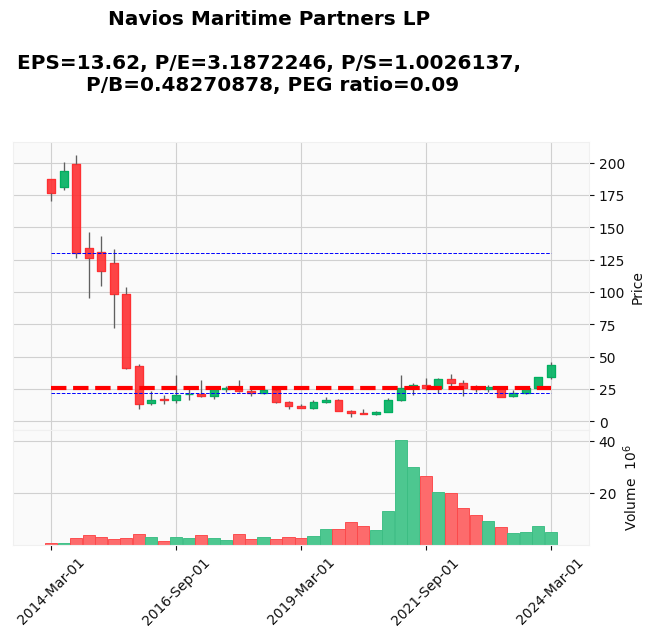

|    | Title                                                                                                                                                                                                                 | Publisher   |   Sentiment |   Days Ago |
|---:|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:------------|------------:|-----------:|
|  0 | [Should Value Investors Buy Navios Maritime Partners (NMM) Stock?](https://finance.yahoo.com/news/value-investors-buy-navios-maritime-134016122.html)                                                                 | Zacks       |   0.168954  |          0 |
|  1 | [Scorpio Tankers Inc. (STNG) Hits Fresh High: Is There Still Room to Run?](https://finance.yahoo.com/news/scorpio-tankers-inc-stng-hits-131511685.html)                                                               | Zacks       |   0.0589336 |          3 |
|  2 | [Zacks.com featured highlights PagSeguro Digital, American Vanguard, Designer Brands, Navios Maritime and Empire State Realty](https://finance.yahoo.com/news/zacks-com-featured-highlights-pagseguro-091600715.html) | Zacks       |   0.0771775 |          5 |
|  3 | [5 Value Stocks With Enticing EV-to-EBITDA Ratios to Own Now](https://finance.yahoo.com/news/5-value-stocks-enticing-ev-100000627.html)                                                                               | Zacks       |   0.0787383 |          6 |
|  4 | [Navios Maritime Partners LP (NMM) Is a Great Choice for 'Trend' Investors, Here's Why](https://finance.yahoo.com/news/navios-maritime-partners-lp-nmm-125008514.html)                                                | Zacks       |   0.117406  |          7 |
|  5 | [Navios Maritime Partners LP (NMM) Shows Fast-paced Momentum But Is Still a Bargain Stock](https://finance.yahoo.com/news/navios-maritime-partners-lp-nmm-125006198.html)                                             | Zacks       |   0.186227  |          7 |
|  6 | [Are You Looking for a Top Momentum Pick? Why Navios Maritime Partners LP (NMM) is a Great Choice](https://finance.yahoo.com/news/looking-top-momentum-pick-why-160003584.html)                                       | Zacks       |   0.093896  |         10 |
|  7 | [Are Investors Undervaluing Navios Maritime Partners (NMM) Right Now?](https://finance.yahoo.com/news/investors-undervaluing-navios-maritime-partners-144012884.html)                                                 | Zacks       |   0.222999  |         18 |

Average new sentiment for <span style='color:yellow'>NMM</span>: <span style='color:red'>**0.1255413035978841**</span>

| Metric           | Value                            |
|:-----------------|:---------------------------------|
| Dividend Date    | 2024-02-14                       |
| Ex-Dividend Date | 2024-02-09                       |
| Earnings Date    | ['May 21, 2024', 'May 27, 2024'] |
| Earnings High    | 2.04                             |
| Earnings Low     | 1.97                             |
| Earnings Average | 2.0                              |
| Revenue High     | 319,000,000.00                   |
| Revenue Low      | 319,000,000.00                   |
| Revenue Average  | 319,000,000.00                   |

## DLB - Dolby Laboratories

https://www.dolby.com


Dolby Laboratories, Inc. creates audio and imaging technologies that transform entertainment at the cinema, DTV transmissions and devices, mobile devices, OTT video and music services, home entertainment devices, and automobiles. The company develops and licenses its audio technologies, such as AAC & HE-AAC, a digital audio codec solution used for a range of media applications; AVC, a digital video codec with high bandwidth efficiency used in various media devices; Dolby AC-4, a digital audio coding technology that delivers new audio experiences to a range of playback devices; and Dolby Atmos technology for cinema and various media devices. Its audio technologies also include DD, a digital audio coding technology that provides multichannel sound to applications; DD+, a digital audio coding technology that offers audio transmission for a range of media applications and devices; Dolby TrueHD, a digital audio coding technology providing encoding for media application; Dolby Vision, an imaging technology for cinema and media devices; and HEVC, a digital video codec with high bandwidth efficiency for media devices. In addition, the company offers digital cinema servers, cinema processors, amplifiers, loudspeakers, and audio and imaging hardware and software products for the cinema, television, broadcast, communication, and entertainment industries. Further, it provides 3-D glasses and kits; and various services to support theatrical and television production for cinema exhibition, broadcast, and home entertainment. The company serves film studios, content creators, post-production facilities, cinema operators, broadcasters, and video game designers. It sells its products directly to the end users, as well as through dealers and distributors worldwide. Dolby Laboratories, Inc. was founded in 1965 and is headquartered in San Francisco, California.

Market Cap: 7954.067968 Millions USD

<Figure size 640x480 with 0 Axes>

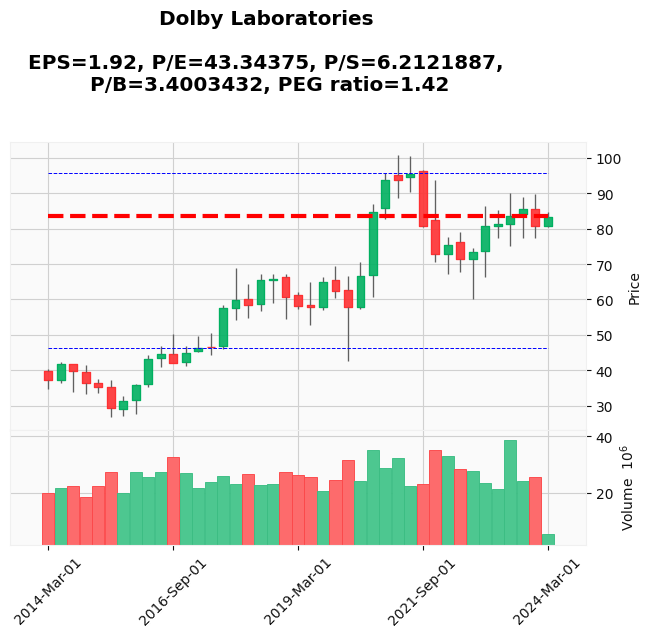

|    | Title                                                                                                                                                                                                                                                                                                                 | Publisher       |   Sentiment |   Days Ago |
|---:|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:----------------|------------:|-----------:|
|  0 | [Dolby Laboratories' (NYSE:DLB) five-year earnings growth trails the respectable shareholder returns](https://finance.yahoo.com/news/dolby-laboratories-nyse-dlb-five-135606779.html)                                                                                                                                 | Simply Wall St. |  0.108851   |         12 |
|  1 | [Why Is Sonos (SONO) Down 2.1% Since Last Earnings Report?](https://finance.yahoo.com/news/why-sonos-sono-down-2-163109705.html)                                                                                                                                                                                      | Zacks           |  0.028851   |         18 |
|  2 | [Insider Sell: SVP, Chief Marketing Officer Todd Pendleton Sells 24,395 Shares of Dolby ...](https://finance.yahoo.com/news/insider-sell-svp-chief-marketing-043655837.html)                                                                                                                                          | GuruFocus.com   |  0.0267857  |         24 |
|  3 | [Dolby Showcases the Immersive power of Dolby Cinema in Latest "Love More" Global Brand Campaign](https://finance.yahoo.com/news/dolby-showcases-immersive-power-dolby-160000831.html)                                                                                                                                | PR Newswire     |  0.284129   |         26 |
|  4 | [Dolby Laboratories Senior Vice President and Chief Financial Officer Robert Park and Senior Vice President of Entertainment John Couling to Host Fireside Chat at the Morgan Stanley Technology, Media & Telecom Conference](https://finance.yahoo.com/news/dolby-laboratories-senior-vice-president-211500063.html) | PR Newswire     |  0.184596   |         27 |
|  5 | [5 Solid Stocks to Buy on a Steady Rise in Consumer Sentiment](https://finance.yahoo.com/news/5-solid-stocks-buy-steady-131200463.html)                                                                                                                                                                               | Zacks           | -0.0202875  |         28 |
|  6 | [3 Audio Video Stocks Worth Watching in a Thriving Industry](https://finance.yahoo.com/news/3-audio-video-stocks-worth-171600382.html)                                                                                                                                                                                | Zacks           |  0.0291559  |         39 |
|  7 | [Dolby Laboratories Inc's Dividend Analysis](https://finance.yahoo.com/news/dolby-laboratories-incs-dividend-analysis-100711609.html)                                                                                                                                                                                 | GuruFocus.com   |  0.00419192 |         42 |

Average new sentiment for <span style='color:yellow'>DLB</span>: <span style='color:red'>**0.0807840779801007**</span>

| Metric           | Value                            |
|:-----------------|:---------------------------------|
| Dividend Date    | 2024-02-22                       |
| Ex-Dividend Date | 2024-02-12                       |
| Earnings Date    | ['May 02, 2024', 'May 06, 2024'] |
| Earnings High    | 1.23                             |
| Earnings Low     | 1.2                              |
| Earnings Average | 1.22                             |
| Revenue High     | 369,540,000.00                   |
| Revenue Low      | 357,100,000.00                   |
| Revenue Average  | 362,550,000.00                   |

# Sector: Real Estate

## RC - Ready Capital Corproation

https://www.readycapital.com


Ready Capital Corporation operates as a real estate finance company in the United States. It operates through two segments: LMM Commercial Real Estate and Small Business Lending. The company originates, acquires, finances, and services lower-to-middle-market (LLM) commercial real estate loans, small business administration (SBA) loans, residential mortgage loans, construction loans, and mortgage-backed securities collateralized primarily by LLM loans, or other real estate-related investments. The LMM Commercial Real Estate segment originates LLM loans across the full life-cycle of an LLM property, including construction, bridge, stabilized, and agency loan origination channels. The Small Business Lending segment acquires, originates, and services owner-occupied loans guaranteed by the SBA under its SBA Section 7(a) Program; and acquires purchased future receivables. The company has elected to be taxed as a real estate investment trust (REIT) and would not be subject to federal corporate income taxes if it distributes at least 90% of its taxable income to its stockholders. The company was formerly known as Sutherland Asset Management Corporation and changed its name to Ready Capital Corporation in September 2018. Ready Capital Corporation was founded in 2007 and is headquartered in New York, New York.

Market Cap: 1592.78656 Millions USD

<Figure size 640x480 with 0 Axes>

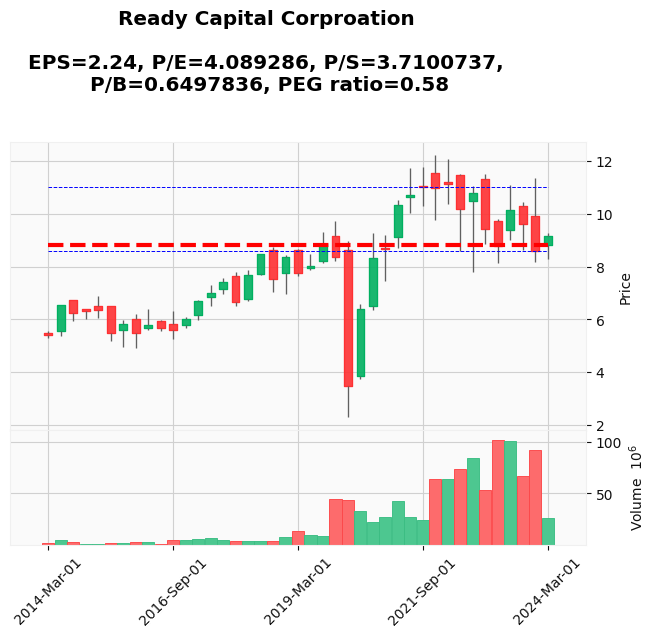

|    | Title                                                                                                                                                                                                         | Publisher                    |   Sentiment |   Days Ago |
|---:|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:-----------------------------|------------:|-----------:|
|  0 | [Ready Capital Corporation Declares First Quarter 2024 Dividends](https://finance.yahoo.com/news/ready-capital-corporation-declares-first-204300988.html)                                                     | GlobeNewswire                |   0.0911932 |         10 |
|  1 | [As Ready Capital (NYSE:RC) rallies 4.7% this past week, investors may now be noticing the company's three-year earnings growth](https://finance.yahoo.com/news/ready-capital-nyse-rc-rallies-101314999.html) | Simply Wall St.              |   0.0911954 |         12 |
|  2 | [12 Most Undervalued REIT Stocks To Buy According To Analysts](https://finance.yahoo.com/news/12-most-undervalued-reit-stocks-112758473.html)                                                                 | Insider Monkey               |   0.106414  |         18 |
|  3 | [Ready Capital Corporation (NYSE:RC) Q4 2023 Earnings Call Transcript](https://finance.yahoo.com/news/ready-capital-corporation-nyse-rc-132711294.html)                                                       | Insider Monkey               |   0.0904156 |         25 |
|  4 | [Q4 2023 Ready Capital Corp Earnings Call](https://finance.yahoo.com/news/q4-2023-ready-capital-corp-044417008.html)                                                                                          | Thomson Reuters StreetEvents |   0.113039  |         26 |
|  5 | [Ready Capital (RC) Reports Q4 Earnings: What Key Metrics Have to Say](https://finance.yahoo.com/news/ready-capital-rc-reports-q4-003011330.html)                                                             | Zacks                        |   0.0922068 |         27 |
|  6 | [Ready Capital Corp Reports Mixed Q4 Results Amid Real Estate Sector Challenges](https://finance.yahoo.com/news/ready-capital-corp-reports-mixed-215912222.html)                                              | GuruFocus.com                |   0.0978814 |         27 |
|  7 | [Ready Capital Corporation Reports Fourth Quarter 2023 Results](https://finance.yahoo.com/news/ready-capital-corporation-reports-fourth-211500717.html)                                                       | GlobeNewswire                |   0.0133961 |         27 |

Average new sentiment for <span style='color:yellow'>RC</span>: <span style='color:red'>**0.08696776383472006**</span>

| Metric           | Value                            |
|:-----------------|:---------------------------------|
| Dividend Date    | 2024-04-30                       |
| Ex-Dividend Date | 2024-03-27                       |
| Earnings Date    | ['May 06, 2024', 'May 10, 2024'] |
| Earnings High    | 0.35                             |
| Earnings Low     | 0.16                             |
| Earnings Average | 0.27                             |
| Revenue High     | 121,600,000.00                   |
| Revenue Low      | 52,000,000.00                    |
| Revenue Average  | 76,370,000.00                    |

## ABR - Arbor Realty Trust

https://arbor.com


Arbor Realty Trust, Inc. invests in a diversified portfolio of structured finance assets in the multifamily, single-family rental, and commercial real estate markets in the United States. The company operates through Structured Business and Agency Business segments. It primarily invests in bridge and mezzanine loans, including junior participating interests in first mortgages, and preferred and direct equity, as well as real estate-related joint ventures, real estate-related notes, and various mortgage-related securities. In addition, the company offers bridge financing products to borrowers who seek short-term capital to be used in an acquisition of property; financing by making preferred equity investments in entities that directly or indirectly own real property; mezzanine financing in the form of loans that are subordinate to a conventional first mortgage loan and senior to the borrower's equity in a transaction; junior participation financing in the form of a junior participating interest in the senior debt; and financing products to borrowers who are looking to acquire conventional, workforce, and affordable single-family housing. Further, it underwrites, originates, sells, and services multifamily mortgage loans through conduit/commercial mortgage-backed securities programs. The company qualifies as a real estate investment trust for federal income tax purposes. It generally would not be subject to federal corporate income taxes if it distributes at least 90% of its taxable income to its stockholders. Arbor Realty Trust, Inc. was incorporated in 2003 and is headquartered in Uniondale, New York.

Market Cap: 2439.254528 Millions USD

<Figure size 640x480 with 0 Axes>

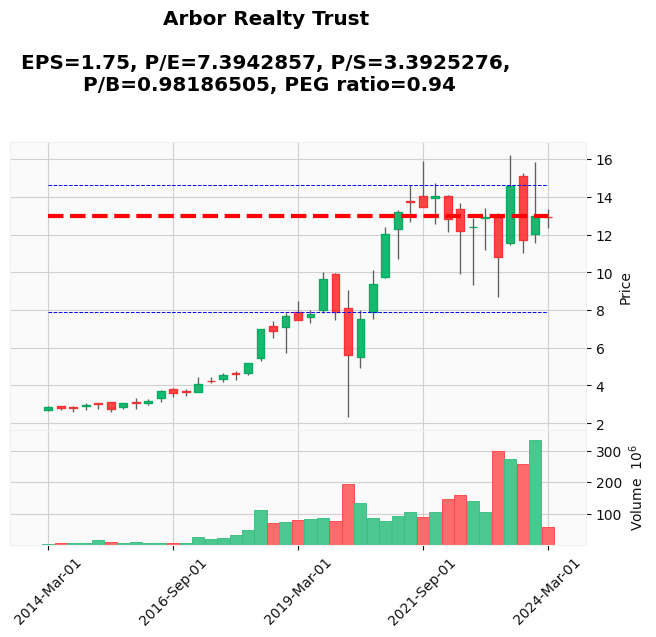

|    | Title                                                                                                                                                                  | Publisher               |   Sentiment |   Days Ago |
|---:|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------------|:------------------------|------------:|-----------:|
|  0 | [Arbor Realty Trust (ABR) Ascends While Market Falls: Some Facts to Note](https://finance.yahoo.com/news/arbor-realty-trust-abr-ascends-215021182.html)                | Zacks                   |   0.0385384 |          0 |
|  1 | [12 Best REIT Dividend Stocks To Buy for 2024](https://finance.yahoo.com/news/12-best-reit-dividend-stocks-120416453.html)                                             | Insider Monkey          |   0.215448  |          0 |
|  2 | [13 Best Dividend-Paying Stocks Under $15](https://finance.yahoo.com/news/13-best-dividend-paying-stocks-150455707.html)                                               | Insider Monkey          |   0.170822  |          1 |
|  3 | [Director William Green Acquires 10,209 Shares of Arbor Realty Trust Inc (ABR)](https://finance.yahoo.com/news/director-william-green-acquires-10-230031574.html)      | GuruFocus.com           |   0.0225895 |          5 |
|  4 | [Arbor Realty Trust (ABR) Stock Sinks As Market Gains: Here's Why](https://finance.yahoo.com/news/arbor-realty-trust-abr-stock-215018001.html)                         | Zacks                   |   0.0274074 |          6 |
|  5 | [Arbor Realty Trust (ABR) Increases Despite Market Slip: Here's What You Need to Know](https://finance.yahoo.com/news/arbor-realty-trust-abr-increases-215019244.html) | Zacks                   |   0.0205062 |         14 |
|  6 | [12 Most Undervalued REIT Stocks To Buy According To Analysts](https://finance.yahoo.com/news/12-most-undervalued-reit-stocks-112758473.html)                          | Insider Monkey          |   0.106414  |         18 |
|  7 | [How to Invest in a Bull Market](https://finance.yahoo.com/m/a547deb1-341f-34f3-b4a9-3d7f70d8455c/how-to-invest-in-a-bull-market.html)                                 | The Wall Street Journal |  -0.1       |         23 |

Average new sentiment for <span style='color:yellow'>ABR</span>: <span style='color:red'>**0.06271572429559007**</span>

| Metric           | Value                            |
|:-----------------|:---------------------------------|
| Dividend Date    | 2024-03-15                       |
| Ex-Dividend Date | 2024-03-01                       |
| Earnings Date    | ['May 03, 2024', 'May 07, 2024'] |
| Earnings High    | 0.46                             |
| Earnings Low     | 0.36                             |
| Earnings Average | 0.43                             |
| Revenue High     | 102,250,000.00                   |
| Revenue Low      | 83,500,000.00                    |
| Revenue Average  | 90,830,000.00                    |

## HASI - Hannon Armstrong Sustainable In

https://www.hasi.com


Hannon Armstrong Sustainable Infrastructure Capital, Inc., through its subsidiaries, engages in the investment in energy efficiency, renewable energy, and sustainable infrastructure markets in the United States. The company's portfolio includes equity investments, commercial and government receivables, real estate, and debt securities. It invests in climate solution, including Behind-the-Meter that distributes energy projects which reduce energy usage or cost through heating, ventilation, and air conditioning systems, as well as lighting, energy controls, roofs, windows, building shells, and/or combined heat and power systems; Grid-Connected, a renewable energy projects that deploy cleaner energy sources, such as solar, solar-plus-storage, and wind to generate power production; and Fuels, Transport, and Nature, a range of real assets spanning high-emitting economic sectors other than the power grid such as transportation and fuels comprising renewable natural gas plants, transportation fleet enhancements, ecological restoration, and other projects. Hannon Armstrong Sustainable Infrastructure Capital, Inc. was founded in 1981 and is headquartered in Annapolis, Maryland.

Market Cap: 3082.377984 Millions USD

<Figure size 640x480 with 0 Axes>

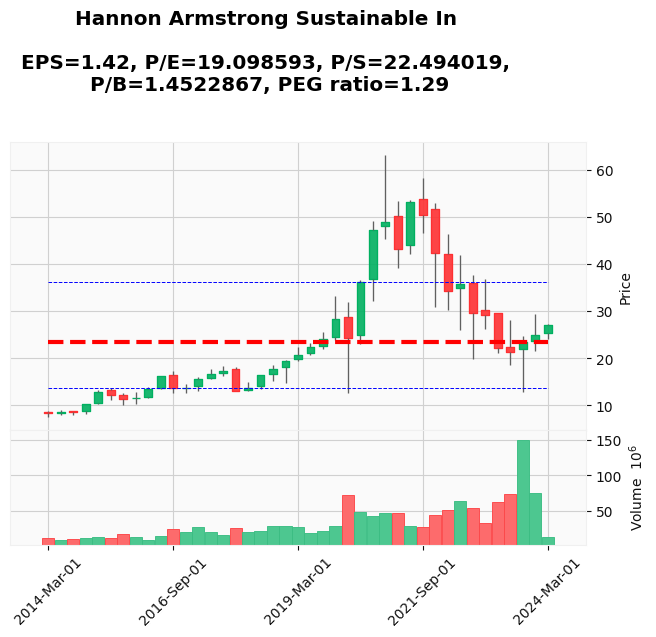

|    | Title                                                                                                                                                                                                                   | Publisher                    |   Sentiment |   Days Ago |
|---:|:------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:-----------------------------|------------:|-----------:|
|  0 | [12 Most Undervalued REIT Stocks To Buy According To Analysts](https://finance.yahoo.com/news/12-most-undervalued-reit-stocks-112758473.html)                                                                           | Insider Monkey               |   0.106414  |         18 |
|  1 | [SunPower Secures More Than $300M in Project Financing Commitments for Industry-Leading Residential Solar and Storage Lease Programs](https://finance.yahoo.com/news/sunpower-secures-more-300m-project-133000220.html) | PR Newswire                  |   0.128565  |         31 |
|  2 | [‘Time to Pull the Trigger,’ Says Oppenheimer About These 3 Stocks](https://finance.yahoo.com/news/time-pull-trigger-says-oppenheimer-131928392.html)                                                                   | TipRanks                     |   0.128216  |         33 |
|  3 | [Hannon Armstrong Sustainable Infrastructure Capital Full Year 2023 Earnings: EPS Beats Expectations, Revenues Lag](https://finance.yahoo.com/news/hannon-armstrong-sustainable-infrastructure-capital-135705362.html)  | Simply Wall St.              |   0.0425    |         37 |
|  4 | [Q4 2023 Hannon Armstrong Sustainable Infrastructure Capital Inc Earnings Call](https://finance.yahoo.com/news/q4-2023-hannon-armstrong-sustainable-190731067.html)                                                     | Thomson Reuters StreetEvents |   0.159326  |         38 |
|  5 | [Hannon Armstrong Sustainable Infrastructure Capital, Inc. (NYSE:HASI) Q4 2023 Earnings Call Transcript](https://finance.yahoo.com/news/hannon-armstrong-sustainable-infrastructure-capital-150109628.html)             | Insider Monkey               |   0.141659  |         38 |
|  6 | [Here's What Key Metrics Tell Us About Hannon Armstrong (HASI) Q4 Earnings](https://finance.yahoo.com/news/heres-key-metrics-tell-us-233010587.html)                                                                    | Zacks                        |   0.126087  |         39 |
|  7 | [Hannon Armstrong: Q4 Earnings Snapshot](https://finance.yahoo.com/news/hannon-armstrong-q4-earnings-snapshot-221150062.html)                                                                                           | Associated Press Finance     |  -0.0833333 |         39 |

Average new sentiment for <span style='color:yellow'>HASI</span>: <span style='color:red'>**0.09367923190398837**</span>

| Metric           | Value                            |
|:-----------------|:---------------------------------|
| Dividend Date    | 2024-04-19                       |
| Ex-Dividend Date | 2024-04-04                       |
| Earnings Date    | ['May 02, 2024', 'May 06, 2024'] |
| Earnings High    | 0.62                             |
| Earnings Low     | 0.44                             |
| Earnings Average | 0.56                             |
| Revenue High     | 90,020,000.00                    |
| Revenue Low      | 53,370,000.00                    |
| Revenue Average  | 71,480,000.00                    |

# Sector: Healthcare

## INVA - Innoviva, Inc.

https://www.inva.com


Innoviva, Inc. engages in the development and commercialization of pharmaceutical products in the United States and internationally. The company's products include RELVAR/BREO ELLIPTA, a once-daily combination medicine consisting of a LABA, vilanterol (VI), an inhaled corticosteroid (ICS), and fluticasone furoate; ANORO ELLIPTA, a once-daily medicine combining a long-acting muscarinic antagonist (LAMA) and umeclidinium bromide (UMEC) with a LABA, VI; GIAPREZA (angiotensin II), a vasoconstrictor to increase blood pressure in adults with septic or other distributive shock; XERAVA (eravacycline) for the treatment of complicated intra-abdominal infections in adults; and XACDURO, a beta lactamase inhibitor for the treatment of hospital-acquired bacterial pneumonia and ventilator-associated bacterial pneumonia. Its development pipeline includes zoliflodacin, a late-stage product candidate, a potential single oral dose cure for the treatment of uncomplicated gonorrhea. Innoviva, Inc. has a strategic partnership with Sarissa Capital Management LP. It has long-acting beta2 agonist (LABA) collaboration agreement with Glaxo Group Limited to develop and commercialize once-daily products for the treatment of chronic obstructive pulmonary disease and asthma. The company was formerly known as Theravance, Inc. and changed its name to Innoviva, Inc. in January 2016. Innoviva, Inc. was incorporated in 1996 and is headquartered in Burlingame, California.

Market Cap: 954.099968 Millions USD

<Figure size 640x480 with 0 Axes>

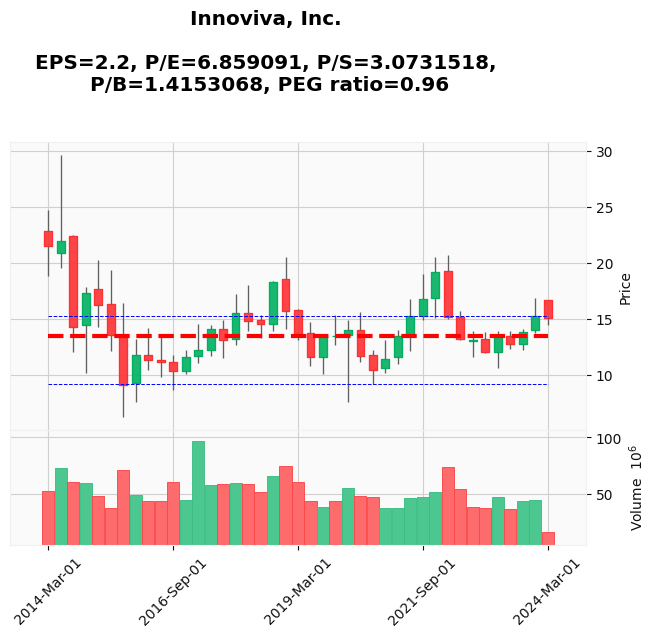

|    | Title                                                                                                                                                                                          | Publisher                |   Sentiment |   Days Ago |
|---:|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:-------------------------|------------:|-----------:|
|  0 | [Armata Pharmaceuticals Announces $35 Million Secured Credit Agreement with Innoviva](https://finance.yahoo.com/news/armata-pharmaceuticals-announces-35-million-210100913.html)               | PR Newswire              |  0.0853929  |         21 |
|  1 | [Innoviva: Q4 Earnings Snapshot](https://finance.yahoo.com/news/innoviva-q4-earnings-snapshot-215635696.html)                                                                                  | Associated Press Finance |  0          |         25 |
|  2 | [Innoviva Inc (INVA) Reports Growth Amidst Challenges in Q4 and Full Year 2023 Financial Results](https://finance.yahoo.com/news/innoviva-inc-inva-reports-growth-213758056.html)              | GuruFocus.com            |  0.138376   |         25 |
|  3 | [Innoviva Reports Fourth Quarter and Full Year 2023 Financial Results; Highlights Recent Company Progress](https://finance.yahoo.com/news/innoviva-reports-fourth-quarter-full-210500190.html) | Business Wire            |  0.072757   |         25 |
|  4 | [Jim Simons Bolsters Position in Innoviva Inc with Recent Acquisition](https://finance.yahoo.com/news/jim-simons-bolsters-position-innoviva-074431904.html)                                    | GuruFocus.com            |  0.00577381 |         41 |
|  5 | [If You Can Only Buy One Biotech Stock in January, It Better Be One of These 3 Names](https://finance.yahoo.com/news/only-buy-one-biotech-stock-231641986.html)                                | InvestorPlace            |  0.168973   |         75 |
|  6 | [Innoviva's (NASDAQ:INVA) investors will be pleased with their 29% return over the last three years](https://finance.yahoo.com/news/innovivas-nasdaq-inva-investors-pleased-133434388.html)    | Simply Wall St.          |  0.113936   |         86 |

Average new sentiment for <span style='color:yellow'>INVA</span>: <span style='color:red'>**0.08360114023681671**</span>

| Metric           | Value                            |
|:-----------------|:---------------------------------|
| Dividend Date    | 2015-09-30                       |
| Ex-Dividend Date | 2015-09-08                       |
| Earnings Date    | ['May 07, 2024', 'May 13, 2024'] |
| Earnings High    | 0.17                             |
| Earnings Low     | 0.17                             |
| Earnings Average | 0.17                             |
| Revenue High     | 68,000,000.00                    |
| Revenue Low      | 68,000,000.00                    |
| Revenue Average  | 68,000,000.00                    |

## ALKS - Alkermes plc

https://www.alkermes.com


Alkermes plc, a biopharmaceutical company, researches, develops, and commercializes pharmaceutical products to address unmet medical needs of patients in therapeutic areas in the United States, Ireland, and internationally. It has a portfolio of proprietary commercial products for the treatment of alcohol dependence, opioid dependence, schizophrenia and bipolar I disorder and a pipeline of clinical and preclinical product candidates in development for neurological disorders. Its marketed products include ARISTADA, an intramuscular injectable suspension for the treatment of schizophrenia; ARISTADA INITIO for the treatment of schizophrenia in adults; VIVITROL for the treatment of alcohol and prevention of opioid dependence; and LYBALVI, an oral atypical antipsychotic drug candidate for the treatment of adults with schizophrenia and bipolar I disorder. It has collaboration agreements primarily with Janssen Pharmaceutica N.V., Janssen Pharmaceutica Inc, and Janssen Pharmaceutica International. The company also offers proprietary technology platforms to third parties to enable them to develop, commercialize, and manufacture products. Alkermes plc was founded in 1987 and is headquartered in Dublin, Ireland.

Market Cap: 4562.845696 Millions USD

<Figure size 640x480 with 0 Axes>

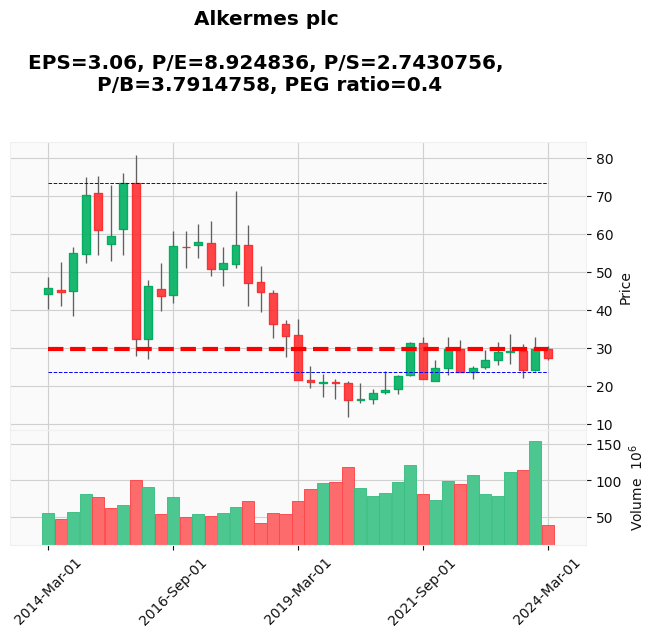

|    | Title                                                                                                                                                                                | Publisher                 |   Sentiment |   Days Ago |
|---:|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:--------------------------|------------:|-----------:|
|  0 | [Are You a Growth Investor? This 1 Stock Could Be the Perfect Pick](https://finance.yahoo.com/news/growth-investor-1-stock-could-134511342.html)                                     | Zacks                     |  0.0940759  |          0 |
|  1 | [How to Find Strong Medical Stocks Slated for Positive Earnings Surprises](https://finance.yahoo.com/news/strong-medical-stocks-slated-positive-130011237.html)                      | Zacks                     |  0.193406   |          0 |
|  2 | [The Cream Of The Crop: 5 Biotechs That Outrank Most Stocks](https://finance.yahoo.com/m/646ae987-4a1c-35a8-8f94-7bfeaae7f4cf/the-cream-of-the-crop%3A-5.html)                       | Investor's Business Daily |  0.00492424 |          4 |
|  3 | [How to Boost Your Portfolio with Top Medical Stocks Set to Beat Earnings](https://finance.yahoo.com/news/boost-portfolio-top-medical-stocks-130004435.html)                         | Zacks                     |  0.202776   |          5 |
|  4 | [Insider Sell: SVP, Chief Commercial Officer Christian Nichols Sells Shares of Alkermes PLC (ALKS)](https://finance.yahoo.com/news/insider-sell-svp-chief-commercial-230159892.html) | GuruFocus.com             |  0.0311966  |          7 |
|  5 | [Alkermes (ALKS) Stock Moves -0.45%: What You Should Know](https://finance.yahoo.com/news/alkermes-alks-stock-moves-0-221519348.html)                                                | Zacks                     |  0.0485185  |         10 |
|  6 | [3 Reasons Why Alkermes (ALKS) Is a Great Growth Stock](https://finance.yahoo.com/news/3-reasons-why-alkermes-alks-164505335.html)                                                   | Zacks                     |  0.154113   |         12 |
|  7 | [Here's Why Alkermes (ALKS) is a Strong Momentum Stock](https://finance.yahoo.com/news/heres-why-alkermes-alks-strong-135006161.html)                                                | Zacks                     |  0.122918   |         13 |

Average new sentiment for <span style='color:yellow'>ALKS</span>: <span style='color:red'>**0.10649106422397239**</span>

| Metric           | Value                 |
|:-----------------|:----------------------|
| Earnings Date    | ['February 15, 2024'] |
| Earnings High    | 0.92                  |
| Earnings Low     | 0.58                  |
| Earnings Average | 0.69                  |
| Revenue High     | 415,010,000.00        |
| Revenue Low      | 366,000,000.00        |
| Revenue Average  | 377,500,000.00        |

# Sector: Financial Services

ERROR:yfinance:BCSF: No price data found, symbol may be delisted (3mo 2014-03-29 -> 2024-03-26)


...

## GBDC - Golub Capital BDC, Inc.

https://www.golubcapitalbdc.com


Golub Capital BDC, Inc. (GBDC) is a business development company and operates as an externally managed closed-end non-diversified management investment company. It invests in debt and minority equity investments in middle-market companies that are, in most cases, sponsored by private equity investors. It typically invests in diversified consumer services, automobiles, healthcare technology, insurance, health care equipment and supplies, hotels, restaurants and leisure, healthcare providers and services, IT services and specialty retails. It seeks to invest in the United States. It primarily invests in first lien traditional senior debt, first lien one stop, junior debt and equity, senior secured, one stop, unitranche, second lien, subordinated and mezzanine loans of middle-market companies, and warrants.

Market Cap: 2763.493376 Millions USD

<Figure size 640x480 with 0 Axes>

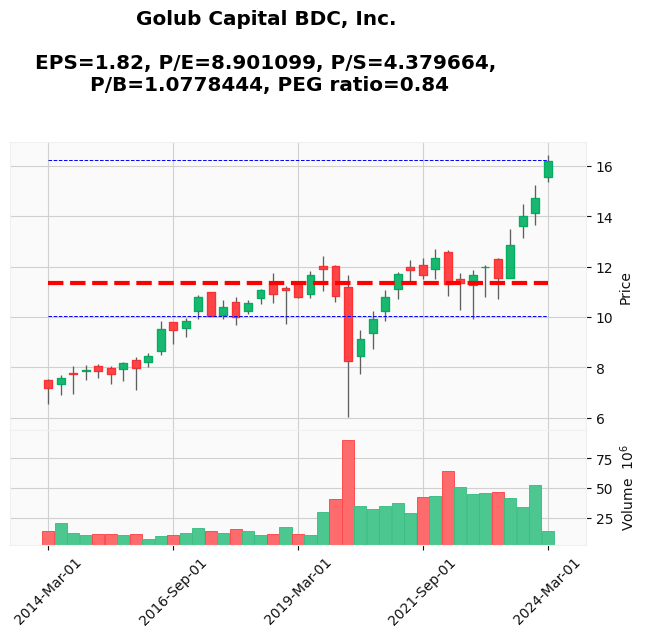

|    | Title                                                                                                                                                                                                                                              | Publisher                |   Sentiment |   Days Ago |
|---:|:---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:-------------------------|------------:|-----------:|
|  0 | [7 Superstar Stocks to Supercharge Your Dividend Returns](https://finance.yahoo.com/news/7-superstar-stocks-supercharge-dividend-203000230.html)                                                                                                   | InvestorPlace            |   0.137515  |          6 |
|  1 | [Golub Capital BDC, Inc. (NASDAQ:GBDC) Q1 2024 Earnings Call Transcript](https://finance.yahoo.com/news/golub-capital-bdc-inc-nasdaq-135326043.html)                                                                                               | Insider Monkey           |   0.112381  |         47 |
|  2 | [Golub Capital BDC (GBDC) Misses Q1 Earnings Estimates](https://finance.yahoo.com/news/golub-capital-bdc-gbdc-misses-224503037.html)                                                                                                               | Zacks                    |   0.0524038 |         49 |
|  3 | [Golub Capital BDC: Fiscal Q1 Earnings Snapshot](https://finance.yahoo.com/news/golub-capital-bdc-fiscal-q1-214716225.html)                                                                                                                        | Associated Press Finance |   0.164773  |         49 |
|  4 | [Golub Capital BDC Inc (GBDC) Reports Solid Earnings with Adjusted NII Per Share Holding Steady](https://finance.yahoo.com/news/golub-capital-bdc-inc-gbdc-213637930.html)                                                                         | GuruFocus.com            |   0.0828986 |         49 |
|  5 | [Golub Capital BDC, Inc. Announces Fiscal Year 2024 First Quarter Financial Results with Second Consecutive Quarter of Highest-Ever Adjusted Net Investment Income](https://finance.yahoo.com/news/golub-capital-bdc-inc-announces-211000920.html) | Business Wire            |   0.0571084 |         49 |
|  6 | [Golub Capital BDC, Inc. Prices Public Offering of $600 Million 6.000% Notes Due 2029](https://finance.yahoo.com/news/golub-capital-bdc-inc-prices-220600416.html)                                                                                 | Business Wire            |   0.017687  |         56 |
|  7 | [Golub Capital BDC (GBDC) Earnings Expected to Grow: What to Know Ahead of Next Week's Release](https://finance.yahoo.com/news/golub-capital-bdc-gbdc-earnings-150016018.html)                                                                     | Zacks                    |   0.113613  |         56 |

Average new sentiment for <span style='color:yellow'>GBDC</span>: <span style='color:red'>**0.09229738872492423**</span>

| Metric           | Value                            |
|:-----------------|:---------------------------------|
| Dividend Date    | 2024-03-29                       |
| Ex-Dividend Date | 2024-02-29                       |
| Earnings Date    | ['May 06, 2024', 'May 10, 2024'] |
| Earnings High    | 0.52                             |
| Earnings Low     | 0.5                              |
| Earnings Average | 0.51                             |
| Revenue High     | 164,400,000.00                   |
| Revenue Low      | 159,160,000.00                   |
| Revenue Average  | 162,410,000.00                   |

## PJT - PJT Partners Inc.

https://www.pjtpartners.com


PJT Partners Inc., an investment bank, provides various strategic and capital markets advisory, restructuring and special situations, and shareholder advisory services to corporations, financial sponsors, institutional investors, and governments worldwide. It offers advisory services to clients on various transactions, including mergers and acquisitions (M&A), spin-offs, activism defense, contested M&A, joint ventures, minority investments, and divestitures. The company also advises private and public company boards and management teams on strategies for building productive investor relationships with a focus on shareholder engagement; and strategic investor relations; environmental, social, and governance matters; and other investor-related matters. In addition, it provides advisory services related to debt and acquisition financings; structured product offerings; public equity raises, including initial public offering and SPAC offerings; and private capital raises for early and later stage companies, as well as other capital structure related matters. Further, the company offers advisory services in financial restructurings and reorganizations; liability management; distressed mergers and acquisitions; and to management teams, corporate boards, sponsors and creditors. Additionally, it provides private fund advisory and fundraising services for a range of investment strategies; and advisory services to general and partners on liquidity and other structured solutions. The company was formerly known as Blackstone Advisory Inc. and changed its name to PJT Partners Inc. in March 2015. PJT Partners Inc. was incorporated in 2014 and is headquartered in New York, New York.

Market Cap: 3693.62048 Millions USD

<Figure size 640x480 with 0 Axes>

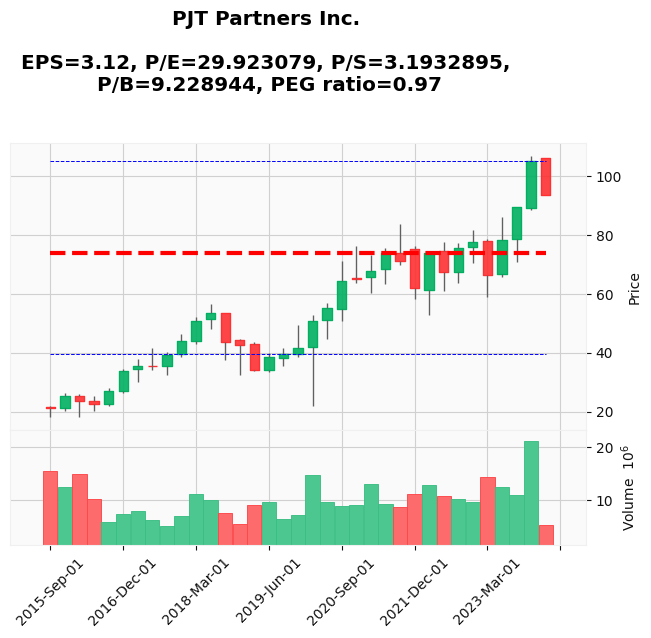

|    | Title                                                                                                                                                                                               | Publisher                    |   Sentiment |   Days Ago |
|---:|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:-----------------------------|------------:|-----------:|
|  0 | [Here’s Why PJT Partners (PJT) Rose in Q4](https://finance.yahoo.com/news/why-pjt-partners-pjt-rose-052143509.html)                                                                                 | Insider Monkey               |   0.0780917 |         43 |
|  1 | [PJT Partners (NYSE:PJT) Is Paying Out A Dividend Of $0.25](https://finance.yahoo.com/news/pjt-partners-nyse-pjt-paying-121348106.html)                                                             | Simply Wall St.              |   0.174678  |         45 |
|  2 | [PJT Partners Inc. (NYSE:PJT) Q4 2023 Earnings Call Transcript](https://finance.yahoo.com/news/pjt-partners-inc-nyse-pjt-141154472.html)                                                            | Insider Monkey               |   0.18144   |         47 |
|  3 | [Q4 2023 PJT Partners Inc Earnings Call](https://finance.yahoo.com/news/q4-2023-pjt-partners-inc-033416641.html)                                                                                    | Thomson Reuters StreetEvents |   0.169914  |         48 |
|  4 | [PJT Partners (PJT) Beats Q4 Earnings and Revenue Estimates](https://finance.yahoo.com/news/pjt-partners-pjt-beats-q4-130003408.html)                                                               | Zacks                        |   0.0598039 |         48 |
|  5 | [PJT Partners Inc. Announces Record Revenues and Robust Earnings for Full Year and Q4 2023](https://finance.yahoo.com/news/pjt-partners-inc-announces-record-120916472.html)                        | GuruFocus.com                |   0.0593802 |         48 |
|  6 | [PJT Partners Inc. Reports Full Year and Fourth Quarter 2023 Results; Announces $500 Million Repurchase Authorization](https://finance.yahoo.com/news/pjt-partners-inc-reports-full-115000957.html) | Business Wire                |   0.037755  |         48 |
|  7 | [Analysts Estimate PJT Partners (PJT) to Report a Decline in Earnings: What to Look Out for](https://finance.yahoo.com/news/analysts-estimate-pjt-partners-pjt-150049967.html)                      | Zacks                        |   0.0887272 |         55 |

Average new sentiment for <span style='color:yellow'>PJT</span>: <span style='color:red'>**0.10622387609114675**</span>

| Metric           | Value                              |
|:-----------------|:-----------------------------------|
| Dividend Date    | 2024-03-20                         |
| Ex-Dividend Date | 2024-03-05                         |
| Earnings Date    | ['April 30, 2024', 'May 06, 2024'] |
| Earnings High    | 0.74                               |
| Earnings Low     | 0.45                               |
| Earnings Average | 0.6                                |
| Revenue High     | 277,310,000.00                     |
| Revenue Low      | 226,100,000.00                     |
| Revenue Average  | 249,000,000.00                     |

# Sector: Consumer Defensive

## PRDO - Perdoceo Education Corporation

https://www.perdoceoed.com


Perdoceo Education Corporation provides postsecondary education through online, campus-based, and blended learning programs in the United States. It operates in two segments, Colorado Technical University and The American InterContinental University System. The Colorado Technical University segment offers academic programs, such as business and management, nursing, healthcare management, computer science, engineering, information systems and technology, project management, cybersecurity, and criminal justice. The American InterContinental University System segment provides academic programs, including business studies, information technologies, education, and health sciences. The company also offers non-degree and professional development programs. In addition, it operates intellipath, a learning platform used to educate students; and a mobile application and two-way messaging platform. The company was formerly known as Career Education Corporation and changed its name to Perdoceo Education Corporation in January 2020. Perdoceo Education Corporation was incorporated in 1994 and is headquartered in Schaumburg, Illinois.

Market Cap: 1160.691968 Millions USD

<Figure size 640x480 with 0 Axes>

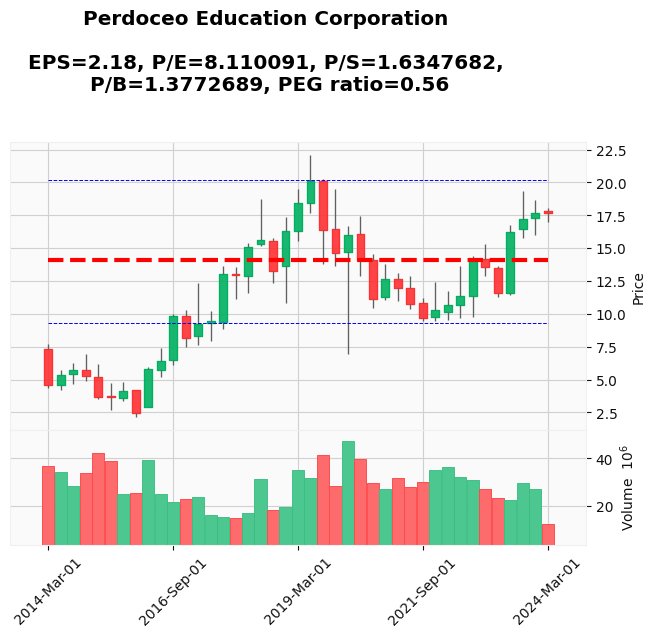

|    | Title                                                                                                                                                                                                                   | Publisher       |   Sentiment |   Days Ago |
|---:|:------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:----------------|------------:|-----------:|
|  0 | [Investing in Perdoceo Education (NASDAQ:PRDO) three years ago would have delivered you a 45% gain](https://finance.yahoo.com/news/investing-perdoceo-education-nasdaq-prdo-132709332.html)                             | Simply Wall St. |   0.19764   |          2 |
|  1 | [Perdoceo Education Corporation's (NASDAQ:PRDO) Fundamentals Look Pretty Strong: Could The Market Be Wrong About The Stock?](https://finance.yahoo.com/news/perdoceo-education-corporations-nasdaq-prdo-130250325.html) | Simply Wall St. |   0.126397  |         16 |
|  2 | [Calculating The Intrinsic Value Of Perdoceo Education Corporation (NASDAQ:PRDO)](https://finance.yahoo.com/news/calculating-intrinsic-value-perdoceo-education-111532036.html)                                         | Simply Wall St. |   0.117928  |         31 |
|  3 | [Perdoceo Education Corporation (NASDAQ:PRDO) Q4 2023 Earnings Call Transcript](https://finance.yahoo.com/news/perdoceo-education-corporation-nasdaq-prdo-150931171.html)                                               | Insider Monkey  |   0.189328  |         32 |
|  4 | [Perdoceo Education Corporation Reports Fourth Quarter and Full Year 2023 Results](https://finance.yahoo.com/news/perdoceo-education-corporation-reports-fourth-211500647.html)                                         | Business Wire   |   0.0272673 |         33 |
|  5 | [Perdoceo Education Corporation Announces Quarterly Dividend](https://finance.yahoo.com/news/perdoceo-education-corporation-announces-quarterly-224500285.html)                                                         | Business Wire   |   0.0797619 |         49 |
|  6 | [Perdoceo Education Corporation Schedules Fourth Quarter Earnings Conference Call for February 21st](https://finance.yahoo.com/news/perdoceo-education-corporation-schedules-fourth-211500944.html)                     | Business Wire   |   0.0813973 |         52 |
|  7 | [At US$17.56, Is It Time To Put Perdoceo Education Corporation (NASDAQ:PRDO) On Your Watch List?](https://finance.yahoo.com/news/us-17-56-time-put-140500340.html)                                                      | Simply Wall St. |   0.151509  |         85 |

Average new sentiment for <span style='color:yellow'>PRDO</span>: <span style='color:red'>**0.12140354309110284**</span>

| Metric           | Value                            |
|:-----------------|:---------------------------------|
| Dividend Date    | 2024-03-15                       |
| Ex-Dividend Date | 2024-02-29                       |
| Earnings Date    | ['May 02, 2024', 'May 06, 2024'] |
| Earnings High    | 0.53                             |
| Earnings Low     | 0.53                             |
| Earnings Average | 0.53                             |
| Revenue High     | 163,320,000.00                   |
| Revenue Low      | 163,320,000.00                   |
| Revenue Average  | 163,320,000.00                   |

# Sector: Technology

# Sector: Consumer Cyclical

## RICK - RCI Hospitality Holdings, Inc.

https://www.rcihospitality.com


RCI Hospitality Holdings, Inc., through its subsidiaries, engages in the hospitality and related businesses in the United States. The company operates through Nightclubs, Bombshells, and Other segments. It owns and/or operates upscale adult nightclubs serving primarily businessmen and professionals under the Rick's Cabaret, Jaguars Club, Tootsie's Cabaret, XTC Cabaret, Club Onyx, Hoops Cabaret and Sports Bar, Scarlett's Cabaret, Diamond Cabaret, Cheetah Gentlemen's Club, PT's Showclub, Playmates Club, Country Rock Cabaret, Temptations Adult Cabaret, Foxy's Cabaret, Vivid Cabaret, Downtown Cabaret, Cabaret East, The Seville, Silver City Cabaret, Heartbreakers Gentlemen's Club, Kappa Men's Club, Baby Dolls, and Chicas Locas names; and a dance club under the Studio 80 brand. The company also owns, operates, and franchises restaurants and sports bars under the Bombshells Restaurant & Bar brand. In addition, it owns a national industry convention and tradeshow; two national industry trade publications; and two national industry award shows, as well as approximately a dozen industry and social media websites, which serves adult nightclubs industry and the adult retail products industry. Further, it holds license to sell Robust Energy Drink in the United States. The company was formerly known as Rick's Cabaret International, Inc. and changed its name to RCI Hospitality Holdings, Inc. in August 2014. RCI Hospitality Holdings, Inc. was founded in 1983 and is based in Houston, Texas.

Market Cap: 518.526272 Millions USD

<Figure size 640x480 with 0 Axes>

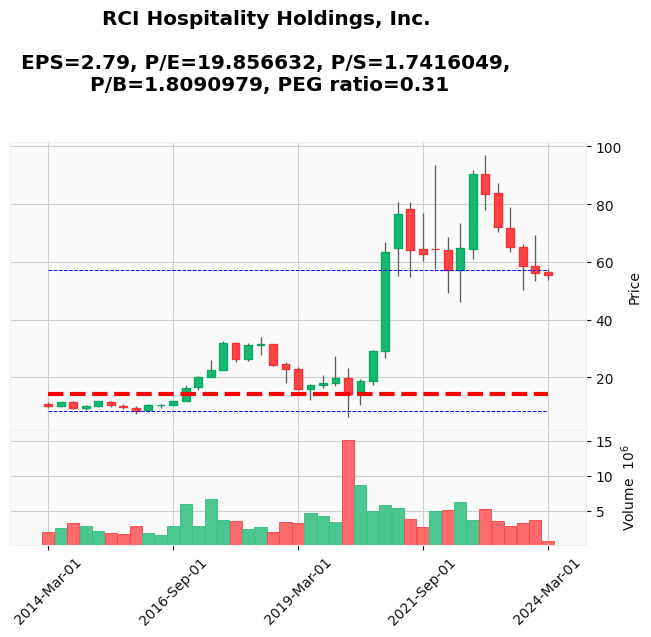

|    | Title                                                                                                                                                                                                    | Publisher       |   Sentiment |   Days Ago |
|---:|:---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:----------------|------------:|-----------:|
|  0 | [Investing in RCI Hospitality Holdings (NASDAQ:RICK) five years ago would have delivered you a 158% gain](https://finance.yahoo.com/news/investing-rci-hospitality-holdings-nasdaq-135235087.html)       | Simply Wall St. |   0.185208  |          7 |
|  1 | [Textron and RCI Hospitality have been highlighted as Zacks Bull and Bear of the Day](https://finance.yahoo.com/news/textron-rci-hospitality-highlighted-zacks-132400341.html)                           | Zacks           |   0.0921907 |         17 |
|  2 | [Bear of the Day: RCI Hospitality Holdings (RICK)](https://finance.yahoo.com/news/bear-day-rci-hospitality-holdings-110000869.html)                                                                      | Zacks           |   0.0633141 |         17 |
|  3 | [Bitcoin Transactions Increasing at RCI's Tootsie's & Scarlett's Adult Clubs in Miami](https://finance.yahoo.com/news/bitcoin-transactions-increasing-rcis-tootsies-140000235.html)                      | PR Newswire     |   0.347857  |         25 |
|  4 | [RCI Announces 33rd Consecutive Quarterly Cash Dividend](https://finance.yahoo.com/news/rci-announces-33rd-consecutive-quarterly-140000537.html)                                                         | PR Newswire     |   0.135     |         26 |
|  5 | [Declining Stock and Decent Financials: Is The Market Wrong About RCI Hospitality Holdings, Inc. (NASDAQ:RICK)?](https://finance.yahoo.com/news/declining-stock-decent-financials-market-194105322.html) | Simply Wall St. |   0.162407  |         27 |
|  6 | [3 Vice Stocks That Can Make a Gloomy February Sizzle](https://finance.yahoo.com/news/3-vice-stocks-gloomy-february-204958602.html)                                                                      | InvestorPlace   |   0.14556   |         28 |
|  7 | [RCI Hospitality Holdings, Inc. Just Missed EPS By 21%: Here's What Analysts Think Will Happen Next](https://finance.yahoo.com/news/rci-hospitality-holdings-inc-just-124756159.html)                    | Simply Wall St. |   0.0858942 |         43 |

Average new sentiment for <span style='color:yellow'>RICK</span>: <span style='color:red'>**0.15217884253021677**</span>

| Metric           | Value                            |
|:-----------------|:---------------------------------|
| Dividend Date    | 2024-03-29                       |
| Ex-Dividend Date | 2024-03-14                       |
| Earnings Date    | ['May 08, 2024', 'May 13, 2024'] |
| Earnings High    | 1.01                             |
| Earnings Low     | 1.01                             |
| Earnings Average | 1.01                             |
| Revenue High     | 75,500,000.00                    |
| Revenue Low      | 73,960,000.00                    |
| Revenue Average  | 74,730,000.00                    |

# Sector: Communication Services

## YELP - Yelp Inc.

https://www.yelp.com


Yelp Inc. operates a platform that connects consumers with local businesses in the United States and internationally. The company's platform covers various categories, including restaurants, shopping, beauty and fitness, health, and other categories, as well as home, local, auto, professional, pets, events, real estate, and financial services. It provides free and paid advertising products to businesses, which include cost-per-click advertising and multi-location Ad products, as well as enables businesses to deliver targeted advertising to large and high-intent audience; and business listing page products. The company also offers other services comprising Yelp Guest Manager, a subscription-based suite of front-of-house management tools for restaurants, nightlife and certain other venues, which include online reservations, a waitlist management solution that allows consumers to check wait times and join waitlists remotely, as well as through hostless kiosks, and seating and server rotation management tools; Yelp Knowledge program that offers business owners local analytics and insights through access to its historical data and other proprietary content; and Yelp Fusion, which offers free access to various basic information through publicly available APIs, and paid access to content and data for consumer-facing enterprise use. In addition, it provides content licensing, as well as allows third-party data providers to update and manage business listing information on behalf of businesses. Further, the company offers its products directly through its sales force; indirectly through partners; and online through its website and business app, as well as non-advertising partner arrangements. It has partnership with Grubhub for providing consumers with a service to place food orders for pickup and delivery. The company was incorporated in 2004 and is based in San Francisco, California.

Market Cap: 2614.487296 Millions USD

<Figure size 640x480 with 0 Axes>

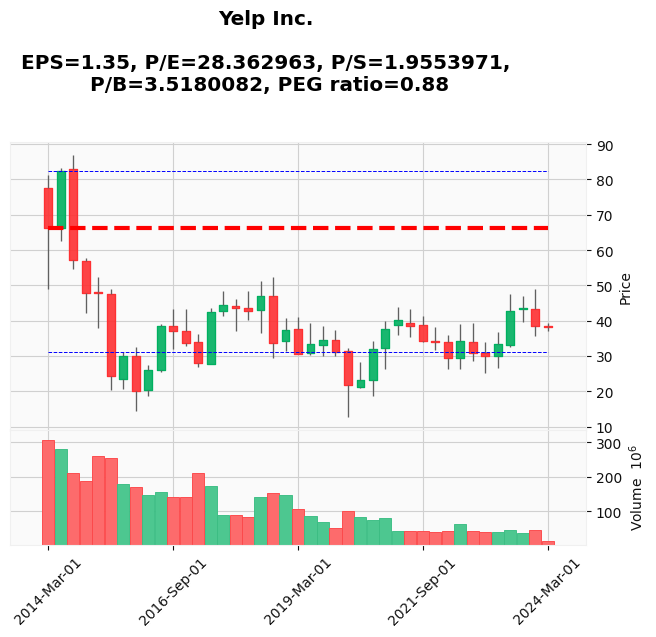

|    | Title                                                                                                                                                                                       | Publisher       |   Sentiment |   Days Ago |
|---:|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:----------------|------------:|-----------:|
|  0 | [Yelp (NYSE:YELP) Might Have The Makings Of A Multi-Bagger](https://finance.yahoo.com/news/yelp-nyse-yelp-might-makings-181151468.html)                                                     | Simply Wall St. |   0.23235   |         21 |
|  1 | [Yelp says going all in on remote work boosted job applications by 43% and led to a more satisfied workforce](https://finance.yahoo.com/news/yelp-says-going-remote-boosted-132531840.html) | Fortune         |   0.170187  |         25 |
|  2 | [Xometry Appoints James Miln as New Chief Financial Officer](https://finance.yahoo.com/news/xometry-appoints-james-miln-chief-120300075.html)                                               | GlobeNewswire   |   0.165909  |         25 |
|  3 | [Yelp Publishes 2023 Trust & Safety Report](https://finance.yahoo.com/news/yelp-publishes-2023-trust-safety-110000727.html)                                                                 | Business Wire   |   0.0833129 |         26 |
|  4 | [Yelp to Participate in the Morgan Stanley Technology, Media & Telecom Conference](https://finance.yahoo.com/news/yelp-participate-morgan-stanley-technology-210500847.html)                | Business Wire   |   0.275118  |         27 |
|  5 | [14 Best Beaten Down Stocks To Buy Right Now](https://finance.yahoo.com/news/14-best-beaten-down-stocks-120431736.html)                                                                     | Insider Monkey  |   0.0984141 |         29 |
|  6 | [Yelp Announces New Employee Inducement Grants Under NYSE Rule 303A.08](https://finance.yahoo.com/news/yelp-announces-employee-inducement-grants-210500462.html)                            | Business Wire   |   0.214205  |         31 |
|  7 | [Yelp Full Year 2023 Earnings: EPS Misses Expectations](https://finance.yahoo.com/news/yelp-full-2023-earnings-eps-131707124.html)                                                          | Simply Wall St. |   0.0672222 |         37 |

Average new sentiment for <span style='color:yellow'>YELP</span>: <span style='color:red'>**0.16333967655915968**</span>

| Metric           | Value                            |
|:-----------------|:---------------------------------|
| Earnings Date    | ['May 02, 2024', 'May 06, 2024'] |
| Earnings High    | 0.09                             |
| Earnings Low     | 0.02                             |
| Earnings Average | 0.04                             |
| Revenue High     | 334,600,000.00                   |
| Revenue Low      | 331,500,000.00                   |
| Revenue Average  | 333,400,000.00                   |

<Figure size 640x480 with 0 Axes>

In [24]:
plot_candle_charts_per_sector(filtered_industries, start_date_str, end_date_str)

In [25]:
indices_to_keep = [combined_metrics['company_labels'].index(label) for label in final_shortlist_labels if label in combined_metrics['company_labels']]

filtered_data = {}
for key, values in combined_metrics.items():
    if isinstance(values, list) and len(values) == len(combined_metrics['company_labels']):  # Ensure the list corresponds to 'company_labels' in size.
        # Keep only the elements at the calculated indices.
        filtered_data[key] = [values[i] for i in indices_to_keep]
    else:
        # Copy the value as-is if it doesn't match the list condition.
        filtered_data[key] = values

# Proof of concept: print the filtered 'totalCashPerShare' and 'company_labels'
print("Filtered 'totalCashPerShare':", filtered_data['totalCashPerShare'])
print("Filtered 'company_labels':", filtered_data['company_labels'])
plot_combined_interactive(filtered_data)

final_industries = fetch_industries(final_shortlist_labels)
plot_sector_distribution_interactive(final_industries, "Interactive Ticker Distribution by Sector for Filtered Tickers")

Filtered 'totalCashPerShare': [9.614, 8.345, 0.821, 4.963, 0.754, 3.061, 4.63, 0.449, 14.866, 9.187, 2.26, 6.538]
Filtered 'company_labels': ['NMM', 'DLB', 'RC', 'ABR', 'HASI', 'INVA', 'ALKS', 'GBDC', 'PJT', 'PRDO', 'RICK', 'YELP']
